# 🏏 IPL — Batter Performance vs Spin Bowling
## Machine Learning Prediction Model

This notebook trains two ML models:
1. **Runs Model** — predicts runs a batter will score on a spin delivery
2. **Dismissal Model** — predicts probability of dismissal on a spin delivery

Then uses both to predict batter performance in any match scenario.

**Data sources used:**
| File | Purpose |
|---|---|
| `Ball_By_Ball_Match_Data.csv` | Main delivery-level training data |
| `2024_players_details.csv` | Bowling styles — identifies spin bowlers |
| `Match_Info.csv` | Season, venue, match metadata |
| `*.json` (Cricsheet) | Extra match files — merged in automatically |

---

## 📦 Step 1 — Imports

In [1]:
import pandas as pd
import numpy as np
import json
import glob
import os
import warnings
warnings.filterwarnings('ignore')

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingClassifier
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import (
    mean_absolute_error, roc_auc_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder
from sklearn.inspection import permutation_importance
import joblib

plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.titlesize'] = 13

print('✅ All libraries loaded')

✅ All libraries loaded


---
## 📂 Step 2 — Load All Data

Put all your files in the **same folder** as this notebook.
The loader will pick up the CSVs and every `*.json` Cricsheet file automatically.

In [ ]:
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
# CONFIG — change these if files are elsewhere
# ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
DATA_FOLDER = '.'                      # CSVs are in same folder as notebook ✓
JSON_FOLDER = '../json/ipl_match'      # ← ADD THIS
SKIP_JSON   = {'teams_info.json'}

# ── Load CSVs ────────────────────────────────────────────────────
balls   = pd.read_csv(os.path.join(DATA_FOLDER, 'Ball_By_Ball_Match_Data.csv'))
players = pd.read_csv(os.path.join(DATA_FOLDER, '2024_players_details.csv'))
matches = pd.read_csv(os.path.join(DATA_FOLDER, 'Match_Info.csv'))

print(f'Ball_By_Ball : {len(balls):,} rows')
print(f'Players      : {len(players):,} rows')
print(f'Matches      : {len(matches):,} rows')

Ball_By_Ball : 278,205 rows
Players      : 261 rows
Matches      : 1,169 rows


In [ ]:
# ── Load all Cricsheet JSON match files ─────────────────────────
def parse_cricsheet(filepath):
    """Parse one Cricsheet JSON → list of delivery dicts."""
    match_id = os.path.splitext(os.path.basename(filepath))[0]
    rows = []
    try:
        with open(filepath, encoding='utf-8') as f:
            m = json.load(f)
    except Exception as e:
        print(f'  ⚠ Could not read {filepath}: {e}')
        return rows

    info   = m.get('info', {})
    season = info.get('season', '')
    venue  = info.get('venue', '')
    teams  = info.get('teams', [])

    for inn_idx, inn in enumerate(m.get('innings', [])):
        bt = inn.get('team', '')
        bwl_team = [t for t in teams if t != bt]
        bwl_team = bwl_team[0] if bwl_team else ''

        for od in inn.get('overs', []):
            ov = od.get('over', -1)
            for bn, ball in enumerate(od.get('deliveries', [])):
                extras  = ball.get('extras', {})
                runs    = ball.get('runs', {})
                wkts    = ball.get('wickets', [])
                rows.append({
                    'ID'              : match_id,
                    'Innings'         : inn_idx + 1,
                    'Overs'           : ov,
                    'BallNumber'      : bn + 1,
                    'Batter'          : ball.get('batter', ''),
                    'Bowler'          : ball.get('bowler', ''),
                    'BatsmanRun'      : runs.get('batter', 0),
                    'ExtrasRun'       : runs.get('extras', 0),
                    'TotalRun'        : runs.get('total', 0),
                    'IsWicketDelivery': int(bool(wkts)),
                    'Kind'            : wkts[0].get('kind', '') if wkts else '',
                    'ExtraType'       : 'wides' if 'wides' in extras else
                                        'noballs' if 'noballs' in extras else np.nan,
                    'BattingTeam'     : bt,
                    'season_json'     : str(season),
                    'venue_json'      : venue,
                })
    return rows


# Find every JSON that is NOT in the skip list
json_files = [
    f for f in sorted(glob.glob(os.path.join(JSON_FOLDER, '*.json')))
    if os.path.basename(f) not in SKIP_JSON
]

print(f'Found {len(json_files)} Cricsheet JSON files — parsing...')
all_json_rows = []
for fp in json_files:
    all_json_rows.extend(parse_cricsheet(fp))

json_balls = pd.DataFrame(all_json_rows) if all_json_rows else pd.DataFrame()

if not json_balls.empty:
    print(f'JSON deliveries parsed : {len(json_balls):,}')
else:
    print('No JSON files found — using CSV data only (that is fine)')

Found 0 Cricsheet JSON files — parsing...
No JSON files found — using CSV data only (that is fine)


In [4]:
# ── Merge CSV + JSON into one master delivery table ─────────────
# Ensure consistent column set before concat
COMMON_COLS = ['ID','Innings','Overs','BallNumber','Batter','Bowler',
               'BatsmanRun','ExtrasRun','TotalRun','IsWicketDelivery',
               'Kind','ExtraType','BattingTeam']

balls_clean = balls[COMMON_COLS].copy()

if not json_balls.empty:
    json_clean = json_balls[COMMON_COLS].copy()
    # Avoid duplicating deliveries that are already in the CSV
    csv_ids = set(balls_clean['ID'].astype(str))
    json_new = json_clean[~json_clean['ID'].astype(str).isin(csv_ids)]
    all_balls = pd.concat([balls_clean, json_new], ignore_index=True)
    print(f'New deliveries added from JSON : {len(json_new):,}')
else:
    all_balls = balls_clean.copy()

# Add season from Match_Info
matches['match_date'] = pd.to_datetime(matches['match_date'])
matches['season']     = matches['match_date'].dt.year
all_balls = all_balls.merge(
    matches[['match_number','season','venue']].rename(columns={'match_number':'ID'}),
    on='ID', how='left'
)

print(f'\nTotal deliveries in master table: {len(all_balls):,}')
print(f'Seasons covered: {sorted(all_balls["season"].dropna().astype(int).unique())}')


Total deliveries in master table: 278,205
Seasons covered: [np.int64(2008), np.int64(2009), np.int64(2010), np.int64(2011), np.int64(2012), np.int64(2013), np.int64(2014), np.int64(2015), np.int64(2016), np.int64(2017), np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


---
## 🧹 Step 3 — Data Cleaning

In [5]:
print('=== Missing Values ===')
print(all_balls.isnull().sum()[all_balls.isnull().sum()>0])

print('\n=== Duplicate rows ===')
dupes = all_balls.duplicated().sum()
print(f'{dupes} duplicates — removing...')
all_balls.drop_duplicates(inplace=True)

# Fix players data: 'Na' string → NaN
players['longBowlingStyles'] = players['longBowlingStyles'].replace('Na', np.nan)

# Standardise old team names
TEAM_ALIAS = {
    'Kings XI Punjab'             : 'Punjab Kings',
    'Delhi Daredevils'            : 'Delhi Capitals',
    'Royal Challengers Bangalore' : 'Royal Challengers Bengaluru',
    'Deccan Chargers'             : 'Sunrisers Hyderabad',
}
all_balls['BattingTeam'] = all_balls['BattingTeam'].replace(TEAM_ALIAS)

print('\n✅ Cleaning complete')

=== Missing Values ===
Kind         264382
ExtraType    263072
dtype: int64

=== Duplicate rows ===
0 duplicates — removing...

✅ Cleaning complete


---
## 🌀 Step 4 — Identify Spin Bowlers & Filter Deliveries

In [6]:
SPIN_TYPES = [
    'right-arm offbreak',
    'legbreak',
    'legbreak googly',
    'slow left-arm orthodox',
    'left-arm wrist-spin'
]

# Build name → spin-type lookup
spin_players = players[players['longBowlingStyles'].isin(SPIN_TYPES)]
spin_map     = dict(zip(spin_players['Name'], spin_players['longBowlingStyles']))

print(f'Spin bowlers identified : {len(spin_map)}')
print(spin_players['longBowlingStyles'].value_counts())

# Remove wides/no-balls (illegal deliveries) — they don't count against the batter
legal = all_balls[~all_balls['ExtraType'].isin(['wides','noballs'])].copy()

# Filter to spin deliveries only
spin = legal[legal['Bowler'].isin(spin_map)].copy()
spin['spin_type'] = spin['Bowler'].map(spin_map)

# Phase of innings
spin['phase'] = pd.cut(
    spin['Overs'],
    bins=[-1, 5, 14, 19],
    labels=['powerplay', 'middle', 'death']
)

print(f'\nTotal legal deliveries   : {len(legal):,}')
print(f'Spin legal deliveries    : {len(spin):,}  ({len(spin)/len(legal)*100:.1f}%)')
print(f'Unique batters vs spin   : {spin["Batter"].nunique()}')

Spin bowlers identified : 116
longBowlingStyles
right-arm offbreak        55
slow left-arm orthodox    26
legbreak                  20
legbreak googly           13
left-arm wrist-spin        2
Name: count, dtype: int64

Total legal deliveries   : 267,990
Spin legal deliveries    : 58,247  (21.7%)
Unique batters vs spin   : 534


---
## ⚙️ Step 5 — Feature Engineering

We build **two levels of features**:
- **Batter-level** (career stats vs spin) — used as features for each delivery
- **Delivery-level** (over, ball, phase, spin type) — context of each prediction

In [7]:
# ── 5a: Batter career stats vs spin ────────────────────────────
batter_feats = spin.groupby('Batter').agg(
    total_balls      = ('BatsmanRun', 'count'),
    total_runs       = ('BatsmanRun', 'sum'),
    dismissals       = ('IsWicketDelivery', 'sum'),
    dots             = ('BatsmanRun', lambda x: (x==0).sum()),
    fours            = ('BatsmanRun', lambda x: (x==4).sum()),
    sixes            = ('BatsmanRun', lambda x: (x==6).sum()),
    ones             = ('BatsmanRun', lambda x: (x==1).sum()),
    twos             = ('BatsmanRun', lambda x: (x==2).sum()),
).reset_index()

batter_feats['sr']           = batter_feats['total_runs'] / batter_feats['total_balls'] * 100
batter_feats['avg']          = batter_feats['total_runs'] / batter_feats['dismissals'].replace(0, np.nan)
batter_feats['avg']          = batter_feats['avg'].fillna(batter_feats['total_runs'])  # not out average
batter_feats['dot_pct']      = batter_feats['dots']    / batter_feats['total_balls'] * 100
batter_feats['boundary_pct'] = (batter_feats['fours'] + batter_feats['sixes']) / batter_feats['total_balls'] * 100
batter_feats['six_pct']      = batter_feats['sixes']   / batter_feats['total_balls'] * 100
batter_feats['wkt_rate']     = batter_feats['dismissals'] / batter_feats['total_balls'] * 100
batter_feats['rotation_pct'] = (batter_feats['ones'] + batter_feats['twos']) / batter_feats['total_balls'] * 100

print(f'Batter features shape: {batter_feats.shape}')
batter_feats[batter_feats['total_balls']>=50].sort_values('sr', ascending=False).head(10)[
    ['Batter','total_balls','total_runs','sr','avg','dot_pct','boundary_pct','wkt_rate']
].round(2)

Batter features shape: (534, 16)


,Batter,total_balls,total_runs,sr,avg,dot_pct,boundary_pct,wkt_rate
446,SP Narine,238,470,197.48,19.58,35.29,31.93,10.08
52,Abhishek Sharma,324,606,187.04,33.67,25.62,24.69,5.56
57,Aniket Verma,60,110,183.33,27.50,33.33,25.00,6.67
360,Priyansh Arya,59,106,179.66,26.50,27.12,23.73,6.78
165,H Klaasen,372,668,179.57,55.67,22.58,22.04,3.23
500,V Sehwag,137,243,177.37,34.71,21.90,23.36,5.11
343,PD Salt,124,216,174.19,21.60,31.45,29.84,8.06
313,N Pooran,497,851,171.23,53.19,33.40,22.54,3.22
392,RM Patidar,302,512,169.54,46.55,24.83,20.53,3.64
234,KR Mayers,84,139,165.48,19.86,38.10,23.81,8.33


In [8]:
# ── 5b: Encode categorical features ─────────────────────────────
le_spin  = LabelEncoder()
le_phase = LabelEncoder()

spin['spin_type_enc'] = le_spin.fit_transform(spin['spin_type'].astype(str))
spin['phase_enc']     = le_phase.fit_transform(spin['phase'].astype(str))

print('Spin type encoding:')
for i, c in enumerate(le_spin.classes_): print(f'  {i} → {c}')
print('\nPhase encoding:')
for i, c in enumerate(le_phase.classes_): print(f'  {i} → {c}')

Spin type encoding:
  0 → left-arm wrist-spin
  1 → legbreak
  2 → legbreak googly
  3 → right-arm offbreak
  4 → slow left-arm orthodox

Phase encoding:
  0 → death
  1 → middle
  2 → powerplay


In [9]:
# ── 5c: Merge batter features into delivery table ────────────────
BATTER_FEAT_COLS = ['Batter','sr','avg','dot_pct','boundary_pct',
                    'six_pct','wkt_rate','rotation_pct']

model_df = spin.merge(
    batter_feats[BATTER_FEAT_COLS].fillna(0),
    on='Batter', how='left'
)

# Final feature set for the model
FEATURES = [
    # Delivery context
    'Overs', 'BallNumber', 'Innings',
    'spin_type_enc', 'phase_enc',
    # Batter career stats vs spin
    'sr', 'avg', 'dot_pct', 'boundary_pct',
    'six_pct', 'wkt_rate', 'rotation_pct',
]

model_df = model_df[FEATURES + ['BatsmanRun', 'IsWicketDelivery']].dropna()

print(f'Final model dataset: {len(model_df):,} deliveries x {len(FEATURES)} features')
print(f'Wicket rate in dataset: {model_df["IsWicketDelivery"].mean()*100:.2f}%')

Final model dataset: 58,247 deliveries x 12 features
Wicket rate in dataset: 4.73%


---
## 🧠 Step 6 — Train the Models

We train two separate models:
- **Model A** — Random Forest Regressor → predicts runs on each delivery
- **Model B** — Gradient Boosting Classifier → predicts dismissal probability

In [10]:
# ── Train / Test Split ───────────────────────────────────────────
X  = model_df[FEATURES]
yr = model_df['BatsmanRun']           # target: runs scored
yw = model_df['IsWicketDelivery']     # target: wicket (0/1)

X_tr, X_te, yr_tr, yr_te, yw_tr, yw_te = train_test_split(
    X, yr, yw, test_size=0.2, random_state=42
)

print(f'Train size : {len(X_tr):,}')
print(f'Test size  : {len(X_te):,}')

Train size : 46,597
Test size  : 11,650


In [11]:
# ── Model A: Runs Prediction (Regressor) ─────────────────────────
print('Training Runs Model (Random Forest Regressor)...')

runs_model = RandomForestRegressor(
    n_estimators  = 200,
    max_depth     = 10,
    min_samples_leaf = 20,
    random_state  = 42,
    n_jobs        = -1
)
runs_model.fit(X_tr, yr_tr)

y_pred_runs = runs_model.predict(X_te)
mae  = mean_absolute_error(yr_te, y_pred_runs)
# Cross-validation MAE
cv_mae = -cross_val_score(runs_model, X, yr, cv=5,
                           scoring='neg_mean_absolute_error', n_jobs=-1).mean()

print(f'  Test MAE        : {mae:.3f} runs per ball')
print(f'  5-Fold CV MAE   : {cv_mae:.3f} runs per ball')
print(f'  Baseline MAE    : {mean_absolute_error(yr_te, [yr_tr.mean()]*len(yr_te)):.3f}  (always predict mean)')
print(f'\n  → Predicting runs per ball with ±{mae:.2f} error on average')

Training Runs Model (Random Forest Regressor)...
  Test MAE        : 1.091 runs per ball
  5-Fold CV MAE   : 1.095 runs per ball
  Baseline MAE    : 1.103  (always predict mean)

  → Predicting runs per ball with ±1.09 error on average


In [12]:
# ── Model B: Dismissal Probability (Classifier) ──────────────────
print('Training Dismissal Model (Gradient Boosting Classifier)...')

wkt_model = GradientBoostingClassifier(
    n_estimators    = 200,
    max_depth       = 4,
    learning_rate   = 0.05,
    subsample       = 0.8,
    random_state    = 42
)
wkt_model.fit(X_tr, yw_tr)

y_pred_wkt   = wkt_model.predict(X_te)
y_proba_wkt  = wkt_model.predict_proba(X_te)[:, 1]
auc          = roc_auc_score(yw_te, y_proba_wkt)
cv_auc       = cross_val_score(wkt_model, X, yw, cv=5,
                                scoring='roc_auc', n_jobs=-1).mean()

print(f'  Test ROC-AUC    : {auc:.3f}')
print(f'  5-Fold CV AUC   : {cv_auc:.3f}')
print(f'  Baseline AUC    : 0.500  (random guess)')
print()
print(classification_report(yw_te, y_pred_wkt, target_names=['Not Out','Wicket']))

Training Dismissal Model (Gradient Boosting Classifier)...
  Test ROC-AUC    : 0.643
  5-Fold CV AUC   : 0.637
  Baseline AUC    : 0.500  (random guess)

              precision    recall  f1-score   support

     Not Out       0.95      1.00      0.98     11095
      Wicket       0.53      0.01      0.03       555

    accuracy                           0.95     11650
   macro avg       0.74      0.51      0.50     11650
weighted avg       0.93      0.95      0.93     11650



---
## 📊 Step 7 — Model Evaluation & Visualisation

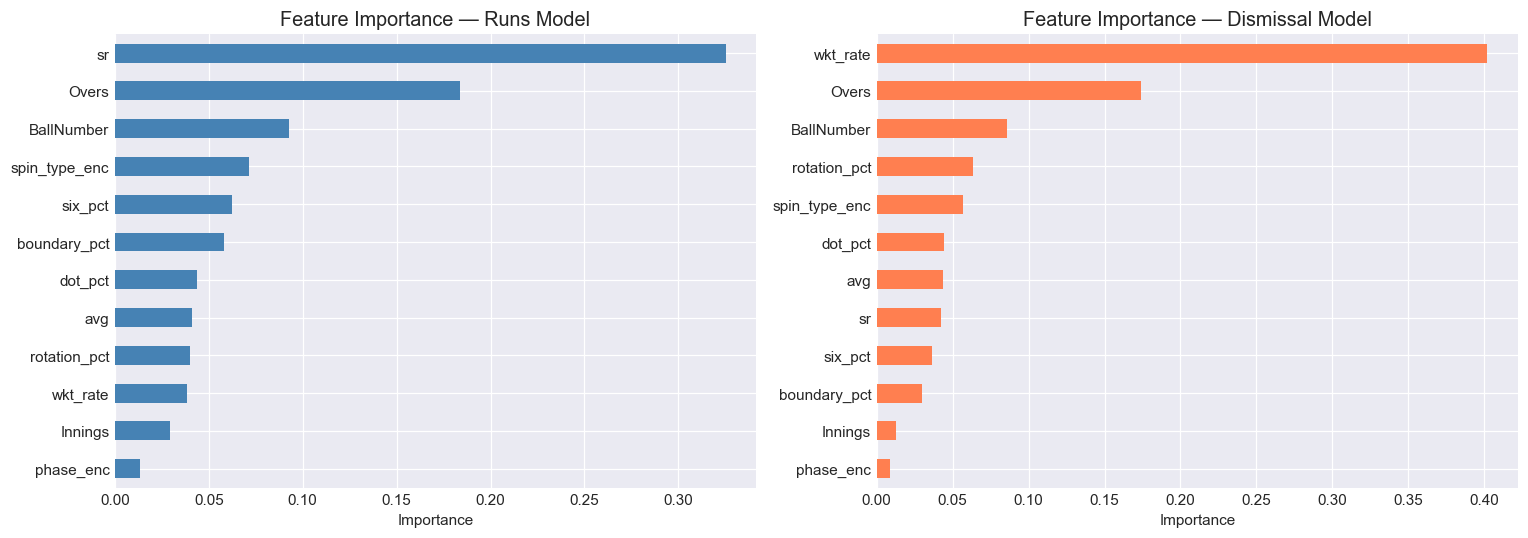

In [13]:
# ── 7a: Feature Importance ───────────────────────────────────────
feat_imp_runs = pd.Series(runs_model.feature_importances_, index=FEATURES).sort_values(ascending=False)
feat_imp_wkt  = pd.Series(wkt_model.feature_importances_,  index=FEATURES).sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

feat_imp_runs.plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Feature Importance — Runs Model')
axes[0].set_xlabel('Importance')
axes[0].invert_yaxis()

feat_imp_wkt.plot(kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Feature Importance — Dismissal Model')
axes[1].set_xlabel('Importance')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

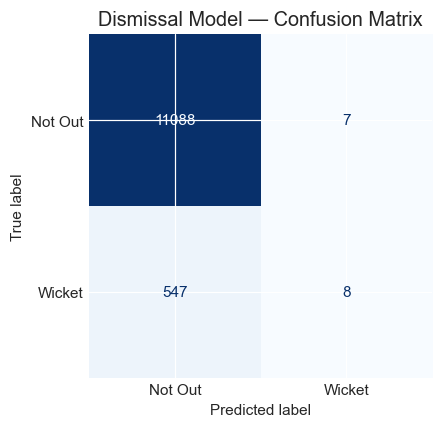

In [14]:
# ── 7b: Confusion Matrix ─────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(
    confusion_matrix(yw_te, y_pred_wkt),
    display_labels=['Not Out', 'Wicket']
).plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Dismissal Model — Confusion Matrix')
plt.tight_layout()
plt.show()

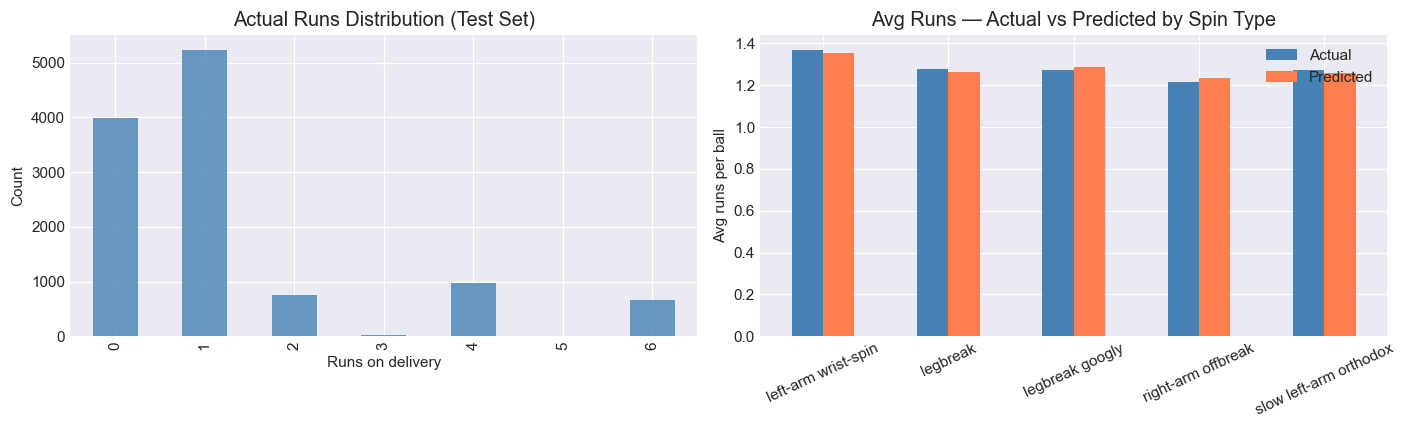

In [15]:
# ── 7c: Predicted vs Actual Runs Distribution ────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Actual distribution
yr_te.value_counts().sort_index().plot(kind='bar', ax=axes[0], color='steelblue', alpha=0.8)
axes[0].set_title('Actual Runs Distribution (Test Set)')
axes[0].set_xlabel('Runs on delivery')
axes[0].set_ylabel('Count')

# Predicted vs actual mean by spin type
model_df_test = X_te.copy()
model_df_test['actual']    = yr_te.values
model_df_test['predicted'] = y_pred_runs
model_df_test['spin_name'] = le_spin.inverse_transform(model_df_test['spin_type_enc'])

comp = model_df_test.groupby('spin_name')[['actual','predicted']].mean()
comp.plot(kind='bar', ax=axes[1], color=['steelblue','coral'])
axes[1].set_title('Avg Runs — Actual vs Predicted by Spin Type')
axes[1].set_xlabel('')
axes[1].set_ylabel('Avg runs per ball')
axes[1].tick_params(axis='x', rotation=25)
axes[1].legend(['Actual','Predicted'])

plt.tight_layout()
plt.show()

---
## 🔮 Step 8 — Predict Batter Performance

**Main function:** `predict_batter(batter_name, spin_type, phase, n_balls)`

Given a batter name, the type of spin being bowled, the phase of the match, and number of balls — it returns:
- Predicted runs
- Predicted strike rate
- Dismissal probability per ball and across the spell

In [16]:
def predict_batter(batter_name, spin_type='right-arm offbreak',
                   phase='middle', innings=1, n_balls=10, verbose=True):
    """
    Predict a batter's performance against spin bowling.

    Parameters
    ----------
    batter_name : str   — batter's name as it appears in the data
    spin_type   : str   — one of: 'right-arm offbreak', 'legbreak',
                          'legbreak googly', 'slow left-arm orthodox',
                          'left-arm wrist-spin'
    phase       : str   — 'powerplay', 'middle', or 'death'
    innings     : int   — 1 or 2
    n_balls     : int   — number of balls to predict over
    verbose     : bool  — print a readable summary

    Returns
    -------
    dict with prediction results
    """
    # ── Get batter's historical features ────────────────────────
    brow = batter_feats[batter_feats['Batter'] == batter_name]

    if brow.empty:
        # Batter not in dataset → use dataset mean as fallback
        if verbose:
            print(f"⚠  '{batter_name}' not found — using dataset average as fallback")
        brow = batter_feats[BATTER_FEAT_COLS[1:]].mean().to_frame().T
        brow['Batter'] = batter_name
        confidence = 'LOW — batter not in training data'
    else:
        nb = brow['total_balls'].values[0]
        confidence = 'HIGH' if nb >= 100 else 'MEDIUM' if nb >= 30 else 'LOW (small sample)'
        if verbose:
            print(f"📊 Historical data: {int(nb)} balls vs spin")

    # ── Encode spin type & phase ─────────────────────────────────
    if spin_type not in le_spin.classes_:
        raise ValueError(f"Unknown spin_type '{spin_type}'. Choose from: {list(le_spin.classes_)}")
    if phase not in le_phase.classes_:
        raise ValueError(f"Unknown phase '{phase}'. Choose from: {list(le_phase.classes_)}")

    spin_enc  = le_spin.transform([spin_type])[0]
    phase_enc = le_phase.transform([phase])[0]

    # ── Build feature row for a typical ball in this scenario ────
    over_map = {'powerplay': 3, 'middle': 10, 'death': 17}
    over_num = over_map[phase]

    feat_vals = [
        over_num,       # Overs
        3,              # BallNumber (mid-over)
        innings,        # Innings
        spin_enc,       # spin_type_enc
        phase_enc,      # phase_enc
        float(brow['sr'].values[0]),
        float(brow['avg'].values[0]),
        float(brow['dot_pct'].values[0]),
        float(brow['boundary_pct'].values[0]),
        float(brow['six_pct'].values[0]),
        float(brow['wkt_rate'].values[0]),
        float(brow['rotation_pct'].values[0]),
    ]

    X_pred = pd.DataFrame([feat_vals], columns=FEATURES)

    # ── Predictions ──────────────────────────────────────────────
    pred_runs_per_ball = float(runs_model.predict(X_pred)[0])
    pred_dismissal_prob = float(wkt_model.predict_proba(X_pred)[0][1])

    pred_runs_total  = round(pred_runs_per_ball * n_balls, 1)
    pred_sr          = round(pred_runs_per_ball * 100, 1)
    dismissal_pct    = round(pred_dismissal_prob * 100, 2)
    dismiss_in_spell = round(1 - (1 - pred_dismissal_prob) ** n_balls, 3)

    # ── Readable output ──────────────────────────────────────────
    if verbose:
        print()
        print('=' * 55)
        print(f'  PREDICTION: {batter_name}')
        print(f'  vs {spin_type}  |  {phase} overs  |  inn {innings}')
        print('=' * 55)
        print(f'  Predicted Strike Rate    : {pred_sr}')
        print(f'  Predicted Runs ({n_balls} balls) : {pred_runs_total}')
        print(f'  Dismissal prob / ball    : {dismissal_pct}%')
        print(f'  Dismissal prob in spell  : {dismiss_in_spell*100:.1f}%')
        print(f'  Confidence               : {confidence}')
        print()
        # Historical comparison
        hist_sr  = round(float(brow['sr'].values[0]), 1)
        hist_wkt = round(float(brow['wkt_rate'].values[0]), 2)
        print(f'  Historical SR vs spin    : {hist_sr}')
        print(f'  Historical wkt rate/ball : {hist_wkt}%')
        print('=' * 55)

    return {
        'batter'           : batter_name,
        'spin_type'        : spin_type,
        'phase'            : phase,
        'predicted_sr'     : pred_sr,
        'predicted_runs'   : pred_runs_total,
        'dismissal_prob_pct' : dismissal_pct,
        'dismiss_in_spell_pct': round(dismiss_in_spell*100, 1),
        'confidence'       : confidence,
    }

print('✅ predict_batter() ready')

✅ predict_batter() ready


In [17]:
# ── Example 1: Single batter prediction ─────────────────────────
# Change these values to predict any batter/scenario

result = predict_batter(
    batter_name = 'V Kohli',           # ← change to any batter
    spin_type   = 'legbreak googly',   # ← spin type
    phase       = 'middle',            # ← 'powerplay', 'middle', 'death'
    innings     = 1,
    n_balls     = 12
)

📊 Historical data: 1715 balls vs spin

  PREDICTION: V Kohli
  vs legbreak googly  |  middle overs  |  inn 1
  Predicted Strike Rate    : 123.3
  Predicted Runs (12 balls) : 14.8
  Dismissal prob / ball    : 2.86%
  Dismissal prob in spell  : 29.4%
  Confidence               : HIGH

  Historical SR vs spin    : 124.0
  Historical wkt rate/ball : 2.33%


In [18]:
# ── Example 2: Predict against all spin types ────────────────────
batter = 'RG Sharma'   # ← change batter here

print(f'\n🏏 {batter} — Performance vs All Spin Types (Middle Overs)\n')
rows = []
for st in SPIN_TYPES:
    r = predict_batter(batter, spin_type=st, phase='middle', n_balls=12, verbose=False)
    rows.append(r)

pred_df = pd.DataFrame(rows)[['spin_type','predicted_sr','predicted_runs',
                                'dismissal_prob_pct','dismiss_in_spell_pct','confidence']]
pred_df.columns = ['Spin Type','Pred SR','Pred Runs (12b)','Dismiss%/ball','Dismiss% in 12b','Confidence']
pred_df.sort_values('Pred SR', ascending=False)


🏏 RG Sharma — Performance vs All Spin Types (Middle Overs)



,Spin Type,Pred SR,Pred Runs (12b),Dismiss%/ball,Dismiss% in 12b,Confidence
0,right-arm offbreak,116.8,14.0,4.90,45.3,HIGH
1,legbreak,116.8,14.0,4.96,45.7,HIGH
2,legbreak googly,116.5,14.0,5.11,46.7,HIGH
3,slow left-arm orthodox,116.4,14.0,4.90,45.3,HIGH
4,left-arm wrist-spin,116.3,14.0,4.96,45.7,HIGH


In [19]:
# ── Example 3: Compare multiple batters in same scenario ─────────
batters_to_compare = [
    'V Kohli', 'RG Sharma', 'MS Dhoni', 'SK Raina', 'KL Rahul'
]  # ← edit this list

scenario = dict(spin_type='slow left-arm orthodox', phase='death', n_balls=12)

print(f"\n🌀 {scenario['spin_type'].upper()} — {scenario['phase'].upper()} OVERS\n")
results = []
for b in batters_to_compare:
    r = predict_batter(b, **scenario, verbose=False)
    results.append(r)

cmp_df = pd.DataFrame(results)[['batter','predicted_sr','predicted_runs',
                                  'dismissal_prob_pct','dismiss_in_spell_pct','confidence']]
cmp_df.columns = ['Batter','Pred SR','Pred Runs','Dismiss%/ball','Dismiss% in 12b','Confidence']
cmp_df.sort_values('Pred SR', ascending=False)


🌀 SLOW LEFT-ARM ORTHODOX — DEATH OVERS



,Batter,Pred SR,Pred Runs,Dismiss%/ball,Dismiss% in 12b,Confidence
3,SK Raina,191.7,23.0,8.01,63.3,HIGH
0,V Kohli,181.1,21.7,4.94,45.6,HIGH
4,KL Rahul,163.3,19.6,5.37,48.5,HIGH
1,RG Sharma,128.0,15.4,10.27,72.7,HIGH
2,MS Dhoni,119.6,14.3,4.42,41.9,HIGH


---
## 📈 Step 9 — Visualise Predictions

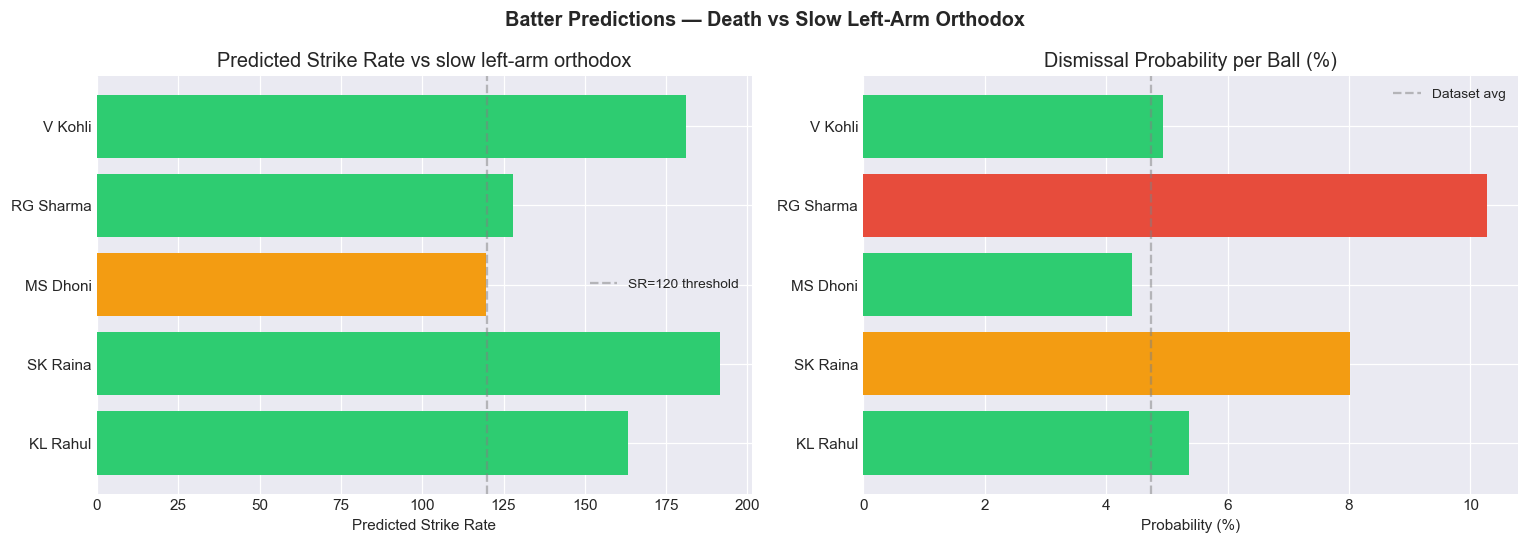

In [20]:
# ── 9a: Predicted SR comparison bar chart ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors_sr = ['#2ecc71' if x > 120 else '#f39c12' if x > 90 else '#e74c3c'
             for x in cmp_df['Pred SR']]
axes[0].barh(cmp_df['Batter'], cmp_df['Pred SR'], color=colors_sr)
axes[0].axvline(120, color='grey', linestyle='--', alpha=0.5, label='SR=120 threshold')
axes[0].set_title(f"Predicted Strike Rate vs {scenario['spin_type']}")
axes[0].set_xlabel('Predicted Strike Rate')
axes[0].invert_yaxis()
axes[0].legend(fontsize=9)

colors_dm = ['#2ecc71' if x < 6 else '#f39c12' if x < 10 else '#e74c3c'
             for x in cmp_df['Dismiss%/ball']]
axes[1].barh(cmp_df['Batter'], cmp_df['Dismiss%/ball'], color=colors_dm)
axes[1].axvline(spin['IsWicketDelivery'].mean()*100, color='grey',
                linestyle='--', alpha=0.5, label='Dataset avg')
axes[1].set_title('Dismissal Probability per Ball (%)')
axes[1].set_xlabel('Probability (%)')
axes[1].invert_yaxis()
axes[1].legend(fontsize=9)

plt.suptitle(f"Batter Predictions — {scenario['phase'].title()} vs {scenario['spin_type'].title()}",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

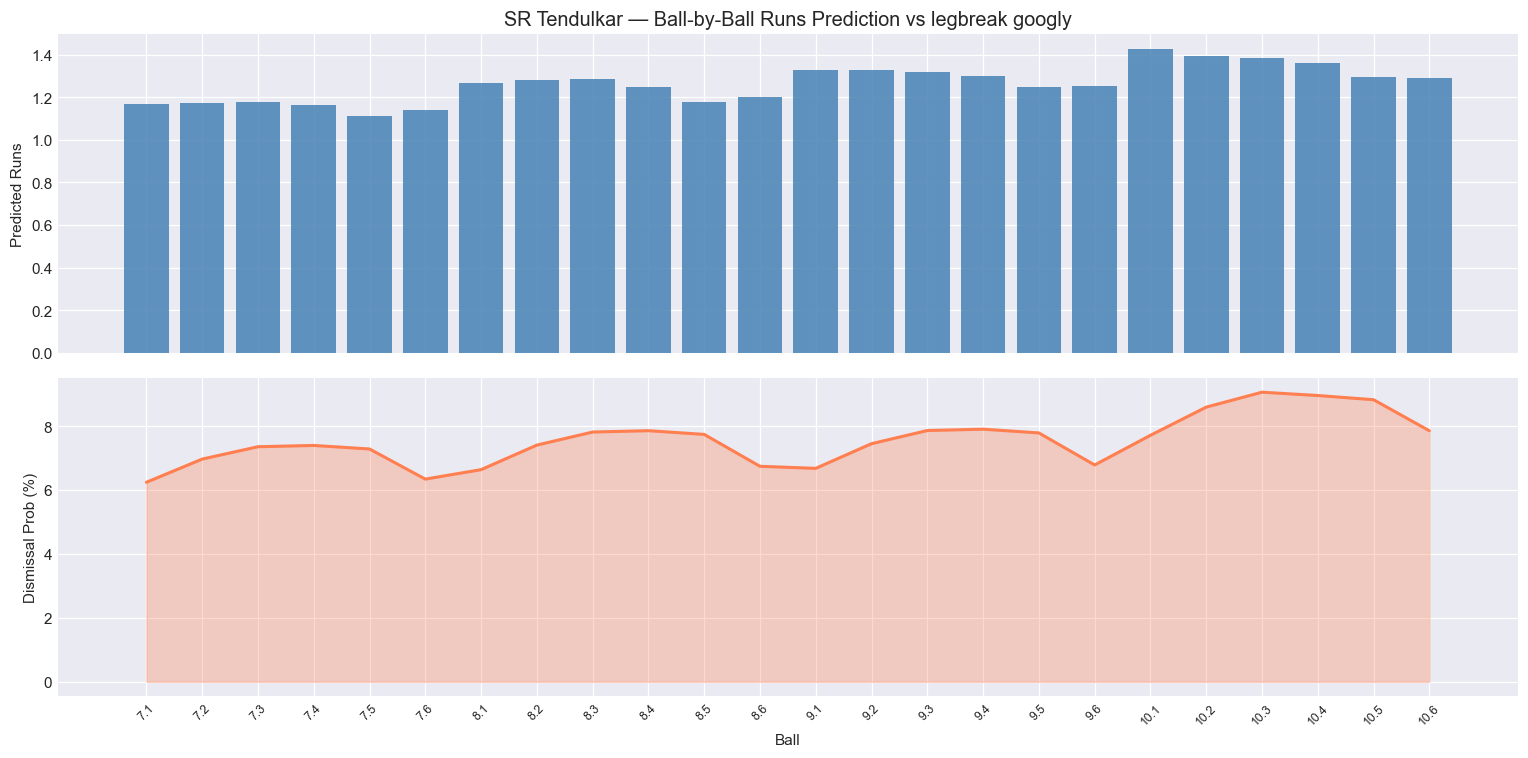

In [21]:
# ── 9b: Predict a full innings spell — ball by ball over 4 overs ─
def predict_spell(batter_name, spin_type, start_over=7, num_overs=4):
    """Simulate a spell over multiple overs, over by over."""
    overs_data = []
    for ov in range(start_over, start_over + num_overs):
        phase = 'powerplay' if ov <= 5 else 'middle' if ov <= 14 else 'death'
        over_rows = []
        for ball in range(1, 7):
            spin_enc  = le_spin.transform([spin_type])[0]
            phase_enc = le_phase.transform([phase])[0]
            brow = batter_feats[batter_feats['Batter']==batter_name]
            if brow.empty: brow = batter_feats[BATTER_FEAT_COLS[1:]].mean().to_frame().T
            feat_vals = [
                ov, ball, 1, spin_enc, phase_enc,
                float(brow['sr'].values[0]), float(brow['avg'].values[0]),
                float(brow['dot_pct'].values[0]), float(brow['boundary_pct'].values[0]),
                float(brow['six_pct'].values[0]), float(brow['wkt_rate'].values[0]),
                float(brow['rotation_pct'].values[0]),
            ]
            X_b = pd.DataFrame([feat_vals], columns=FEATURES)
            r   = float(runs_model.predict(X_b)[0])
            d   = float(wkt_model.predict_proba(X_b)[0][1])
            over_rows.append({'over':ov,'ball':ball,'pred_runs':r,'dismiss_prob':d*100})
        overs_data.append(pd.DataFrame(over_rows))

    spell_df = pd.concat(overs_data)
    spell_df['label'] = spell_df['over'].astype(str) + '.' + spell_df['ball'].astype(str)
    return spell_df


batter = 'SR Tendulkar'          # ← change batter
spin   = 'legbreak googly'  # ← change spin type

spell = predict_spell(batter, spin, start_over=7, num_overs=4)

fig, axes = plt.subplots(2, 1, figsize=(14, 7), sharex=True)

axes[0].bar(spell['label'], spell['pred_runs'], color='steelblue', alpha=0.85)
axes[0].set_ylabel('Predicted Runs')
axes[0].set_title(f'{batter} — Ball-by-Ball Runs Prediction vs {spin}')

axes[1].fill_between(range(len(spell)), spell['dismiss_prob'],
                     alpha=0.3, color='coral')
axes[1].plot(range(len(spell)), spell['dismiss_prob'], color='coral', linewidth=2)
axes[1].set_ylabel('Dismissal Prob (%)')
axes[1].set_xlabel('Ball')
axes[1].set_xticks(range(len(spell)))
axes[1].set_xticklabels(spell['label'], rotation=45, fontsize=8)

plt.tight_layout()
plt.show()

---
## 🏆 Step 10 — Top Batters vs Spin (Historical + Predicted)

In [22]:
# Batters with 50+ balls vs spin — predict SR for all of them
qualified = batter_feats[batter_feats['total_balls'] >= 50]['Batter'].tolist()
print(f'Qualifying batters (50+ balls): {len(qualified)}')

all_preds = []
for b in qualified:
    r = predict_batter(b, spin_type='right-arm offbreak',
                       phase='middle', n_balls=12, verbose=False)
    hist = batter_feats[batter_feats['Batter']==b].iloc[0]
    r['hist_sr']    = round(hist['sr'], 1)
    r['total_balls'] = int(hist['total_balls'])
    all_preds.append(r)

pred_all = pd.DataFrame(all_preds).sort_values('predicted_sr', ascending=False)

# Show top 20 by predicted SR
print('\nTop 20 batters — Predicted SR vs Right-arm Offbreak (Middle Overs)')
pred_all.head(20)[['batter','hist_sr','predicted_sr','predicted_runs',
                    'dismissal_prob_pct','total_balls','confidence']].to_string(index=False)

Qualifying batters (50+ balls): 188

Top 20 batters — Predicted SR vs Right-arm Offbreak (Middle Overs)


'             batter  hist_sr  predicted_sr  predicted_runs  dismissal_prob_pct  total_balls confidence\n          SP Narine    197.5         227.2            27.3                6.51          238       HIGH\n       Aniket Verma    183.3         202.6            24.3                6.05           60     MEDIUM\n      Priyansh Arya    179.7         183.6            22.0                8.57           59     MEDIUM\n           V Sehwag    177.4         179.5            21.5                4.64          137       HIGH\n          KR Mayers    165.5         176.5            21.2               10.35           84     MEDIUM\n             JJ Roy    161.2         174.4            20.9                5.46          134       HIGH\n    Abhishek Sharma    187.0         172.2            20.7                6.60          324       HIGH\n            PD Salt    174.2         170.3            20.4                8.84          124       HIGH\n             N Rana    143.1         167.4            20.1     

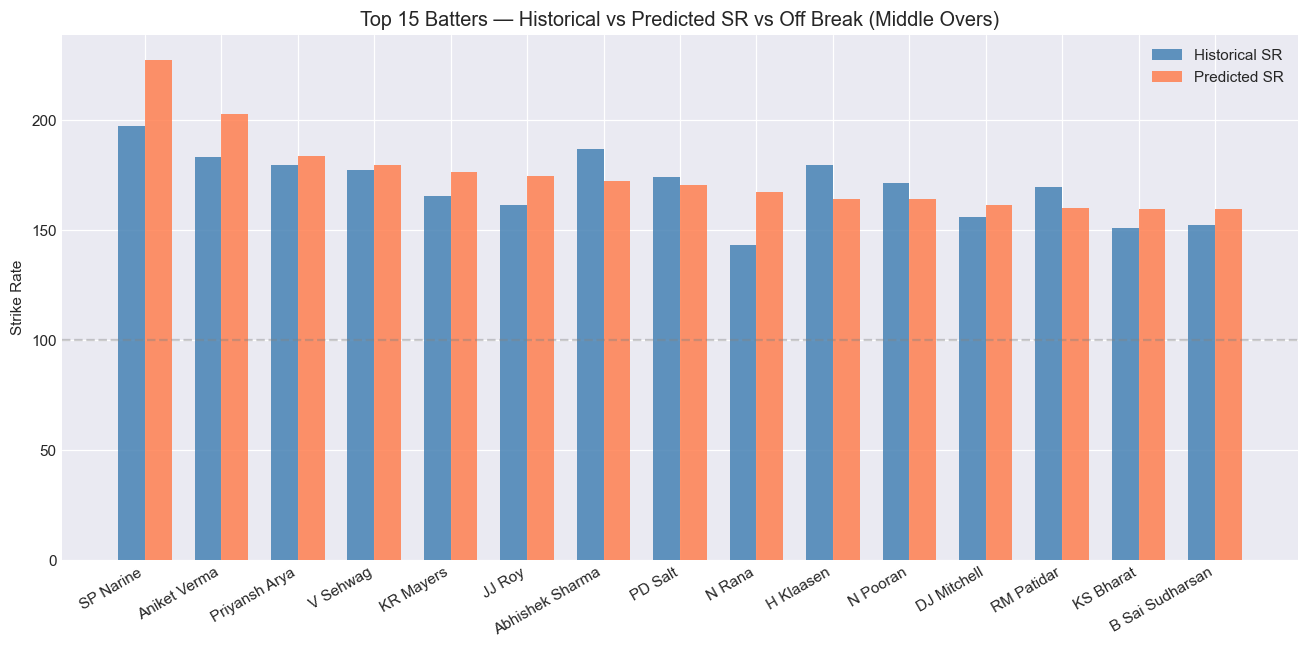

In [23]:
# ── Top 15 chart ─────────────────────────────────────────────────
top15 = pred_all.head(15)

fig, ax = plt.subplots(figsize=(12, 6))
x = range(len(top15))
w = 0.35

ax.bar([i - w/2 for i in x], top15['hist_sr'],       width=w, label='Historical SR', color='steelblue', alpha=0.85)
ax.bar([i + w/2 for i in x], top15['predicted_sr'],  width=w, label='Predicted SR',  color='coral',     alpha=0.85)
ax.set_xticks(x)
ax.set_xticklabels(top15['batter'], rotation=30, ha='right')
ax.set_ylabel('Strike Rate')
ax.set_title('Top 15 Batters — Historical vs Predicted SR vs Off Break (Middle Overs)')
ax.legend()
ax.axhline(100, color='grey', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

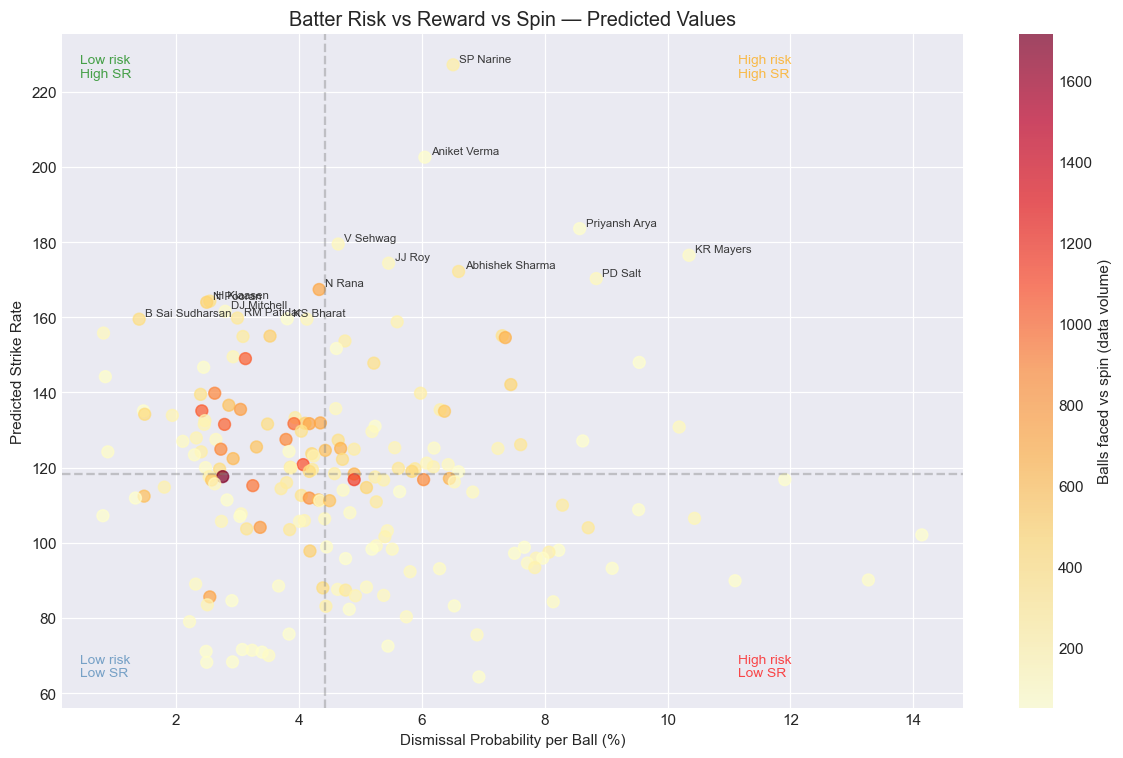

In [24]:
# ── SR vs Dismissal risk scatter ─────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 7))

sc = ax.scatter(
    pred_all['dismissal_prob_pct'],
    pred_all['predicted_sr'],
    c=pred_all['total_balls'], cmap='YlOrRd',
    s=60, alpha=0.7
)
plt.colorbar(sc, ax=ax, label='Balls faced vs spin (data volume)')

# Annotate top 15 by predicted SR
for _, row in pred_all.head(15).iterrows():
    ax.annotate(row['batter'],
                (row['dismissal_prob_pct'], row['predicted_sr']),
                fontsize=7.5, alpha=0.9, xytext=(4,2), textcoords='offset points')

# Quadrant lines
ax.axvline(pred_all['dismissal_prob_pct'].median(), color='grey', linestyle='--', alpha=0.4)
ax.axhline(pred_all['predicted_sr'].median(),       color='grey', linestyle='--', alpha=0.4)

# Quadrant labels
ax.text(0.02, 0.97, 'Low risk\nHigh SR', transform=ax.transAxes,
        fontsize=9, color='green', va='top', alpha=0.7)
ax.text(0.75, 0.97, 'High risk\nHigh SR', transform=ax.transAxes,
        fontsize=9, color='orange', va='top', alpha=0.7)
ax.text(0.02, 0.08, 'Low risk\nLow SR', transform=ax.transAxes,
        fontsize=9, color='steelblue', va='top', alpha=0.7)
ax.text(0.75, 0.08, 'High risk\nLow SR', transform=ax.transAxes,
        fontsize=9, color='red', va='top', alpha=0.7)

ax.set_xlabel('Dismissal Probability per Ball (%)')
ax.set_ylabel('Predicted Strike Rate')
ax.set_title('Batter Risk vs Reward vs Spin — Predicted Values')
plt.tight_layout()
plt.show()

---
## 💾 Step 11 — Save Models & Results

In [25]:
# Save trained models
joblib.dump(runs_model,  'model_runs.pkl')
joblib.dump(wkt_model,   'model_wicket.pkl')
joblib.dump(le_spin,     'encoder_spin.pkl')
joblib.dump(le_phase,    'encoder_phase.pkl')

# Save batter features and predictions
batter_feats.to_csv('batter_features.csv', index=False)
pred_all.to_csv('all_batter_predictions.csv', index=False)

print('Saved:')
print('  model_runs.pkl            — runs prediction model')
print('  model_wicket.pkl          — dismissal prediction model')
print('  encoder_spin.pkl          — spin type label encoder')
print('  encoder_phase.pkl         — phase label encoder')
print('  batter_features.csv       — per-batter historical stats')
print('  all_batter_predictions.csv — predictions for all qualified batters')

Saved:
  model_runs.pkl            — runs prediction model
  model_wicket.pkl          — dismissal prediction model
  encoder_spin.pkl          — spin type label encoder
  encoder_phase.pkl         — phase label encoder
  batter_features.csv       — per-batter historical stats
  all_batter_predictions.csv — predictions for all qualified batters


In [26]:
# ── Reload and use saved model later ─────────────────────────────
# Uncomment to use a previously saved model without retraining
#
# runs_model = joblib.load('model_runs.pkl')
# wkt_model  = joblib.load('model_wicket.pkl')
# le_spin    = joblib.load('encoder_spin.pkl')
# le_phase   = joblib.load('encoder_phase.pkl')
# batter_feats = pd.read_csv('batter_features.csv')

---
## 🎯 Quick Reference

### How to predict any batter
```python
predict_batter(
    batter_name = 'V Kohli',
    spin_type   = 'legbreak googly',  # or 'right-arm offbreak', 'slow left-arm orthodox', etc.
    phase       = 'middle',           # 'powerplay', 'middle', 'death'
    innings     = 1,
    n_balls     = 12
)
```

### Available spin types
| Code | Description |
|---|---|
| `right-arm offbreak` | Off-spin, turns into right-hander |
| `legbreak` | Leg-spin, turns away from right-hander |
| `legbreak googly` | Leg-spin with googly variation |
| `slow left-arm orthodox` | Left-arm spin (like Jadeja) |
| `left-arm wrist-spin` | Chinaman bowling |

### Model outputs explained
| Output | Meaning |
|---|---|
| `predicted_sr` | Strike rate the model expects for this batter in this scenario |
| `predicted_runs` | Total runs over `n_balls` at that strike rate |
| `dismissal_prob_pct` | % chance of dismissal on any single delivery |
| `dismiss_in_spell_pct` | % chance of getting out at least once over the `n_balls` spell |
| `confidence` | Based on sample size — HIGH = 100+ balls in training data |

In [27]:
import joblib, pandas as pd, numpy as np
from sklearn.preprocessing import LabelEncoder

In [28]:
runs_model   = joblib.load('model_runs.pkl')
wkt_model    = joblib.load('model_wicket.pkl')
le_spin      = joblib.load('encoder_spin.pkl')
le_phase     = joblib.load('encoder_phase.pkl')
batter_feats = pd.read_csv('batter_features.csv')

In [29]:
predict_batter('SR Tendulkar', spin_type='legbreak googly', phase='middle', n_balls=12)


📊 Historical data: 174 balls vs spin

  PREDICTION: SR Tendulkar
  vs legbreak googly  |  middle overs  |  inn 1
  Predicted Strike Rate    : 138.2
  Predicted Runs (12 balls) : 16.6
  Dismissal prob / ball    : 9.06%
  Dismissal prob in spell  : 68.0%
  Confidence               : HIGH

  Historical SR vs spin    : 127.0
  Historical wkt rate/ball : 6.32%


{'batter': 'SR Tendulkar',
 'spin_type': 'legbreak googly',
 'phase': 'middle',
 'predicted_sr': 138.2,
 'predicted_runs': 16.6,
 'dismissal_prob_pct': 9.06,
 'dismiss_in_spell_pct': 68.0,
 'confidence': 'HIGH'}